In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = "protein_dataset.tsv"

df = pd.read_csv(dataset, sep="\t", na_values=["-"])

total_rows = len(df)

null_counts = df.isna().sum()
non_null_counts = df.notna().sum()

null_percentages = (null_counts / total_rows * 100).round(2)
non_null_percentages = (non_null_counts / total_rows * 100).round(2)

results = pd.DataFrame(
    {
        "Null Count": null_counts,
        "Null %": null_percentages,
        "Non-Null Count": non_null_counts,
        "Non-Null %": non_null_percentages,
    },
    index=df.columns,
)

print(results)

                    Null Count  Null %  Non-Null Count  Non-Null %
UniProt_ID                   0    0.00           29496      100.00
PDB_wild                  1812    6.14           27684       93.86
SEC_STR                  12593   42.69           16903       57.31
ASA                      14901   50.52           14595       49.48
pH                          71    0.24           29425       99.76
T_(C)                    15014   50.90           14482       49.10
Tm_(C)                   14911   50.55           14585       49.45
∆Tm_(C)                  22862   77.51            6634       22.49
∆H_(kcal/mol)            24428   82.82            5068       17.18
∆Cp_(kcal/mol)           26378   89.43            3118       10.57
∆HvH_(kcal/mol)          24338   82.51            5158       17.49
∆G_(kcal/mol)            28075   95.18            1421        4.82
∆∆G_(kcal/mol)           26526   89.93            2970       10.07
m_(kcal/mol/M)           22239   75.40            7257       2

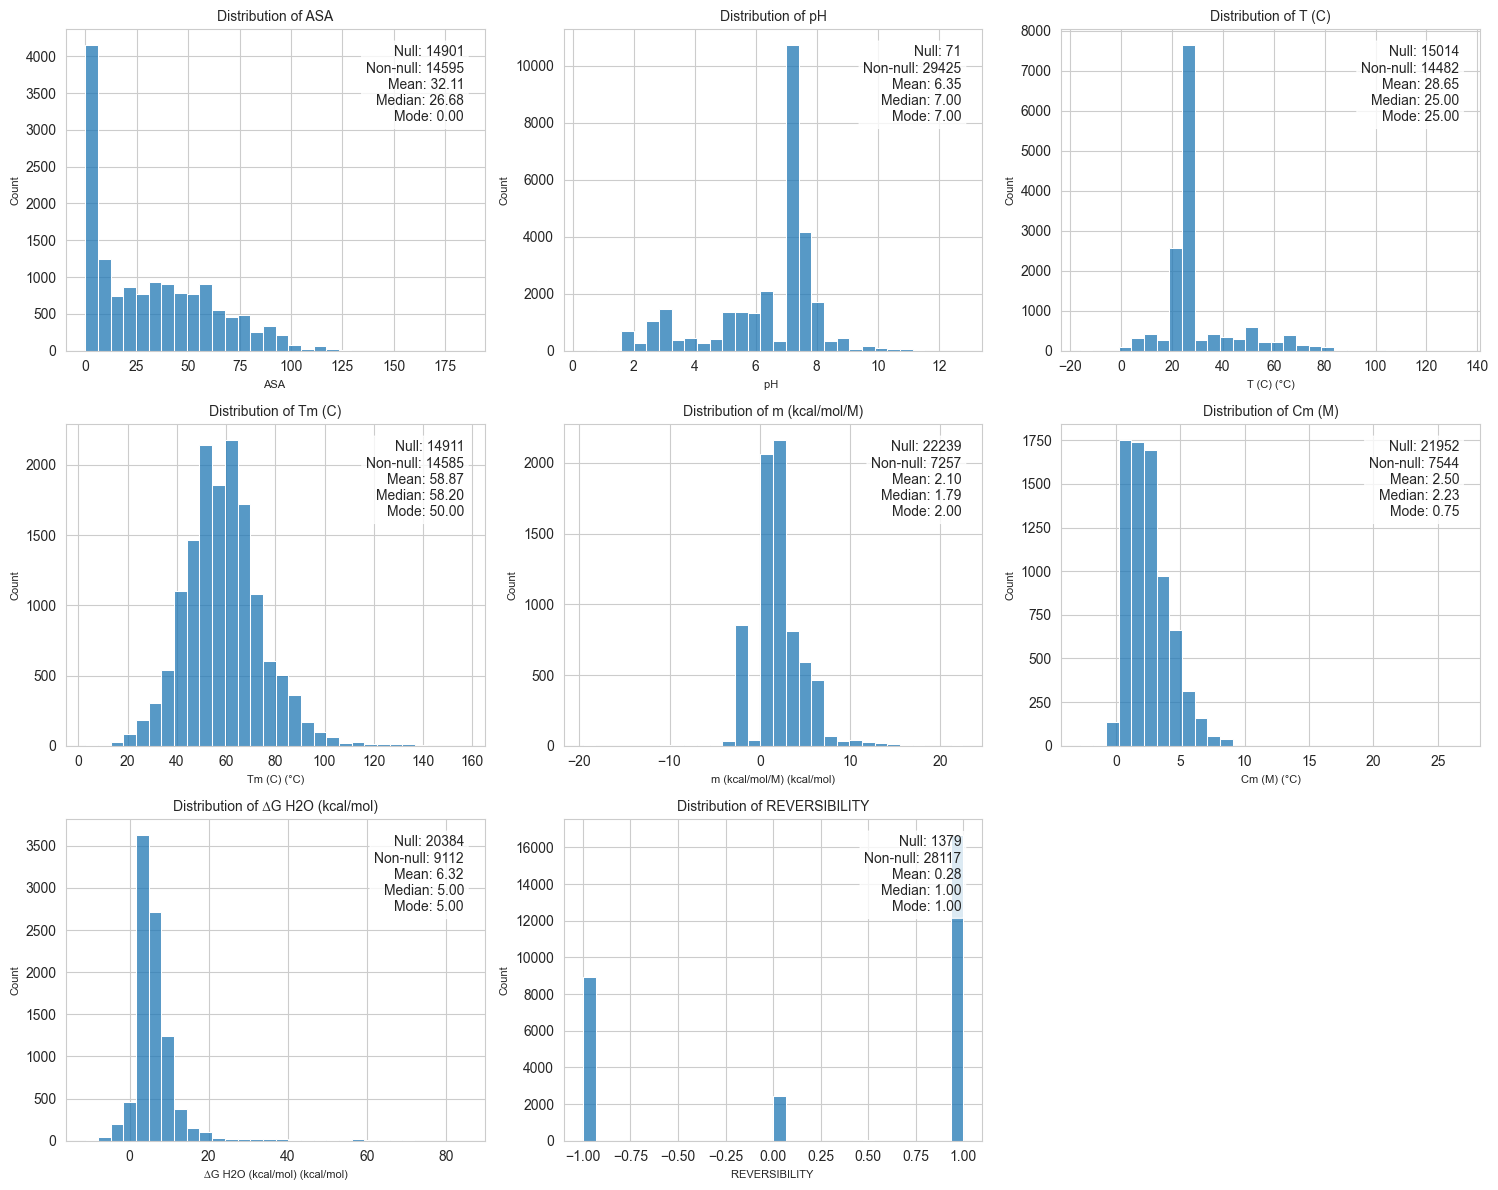

In [20]:
def plot_distribution(df, column_name, ax):
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    
    null_count = df[column_name].isnull().sum()
    non_null_count = df[column_name].notnull().sum()
    
    sns.histplot(data=df, x=column_name, bins=30, kde=False, ax=ax)
    
    formatted_name = column_name.replace('_', ' ').replace('(', '(').replace(')', ')')
    ax.set_title(f'Distribution of {formatted_name}', fontsize=10)
    
    units = ''
    if 'C' in column_name:
        units = '(°C)'
    elif 'kcal' in column_name:
        units = '(kcal/mol)'
    elif 'M' in column_name and not 'mol' in column_name:
        units = '(M)'
        
    ax.set_xlabel(f'{formatted_name} {units}', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    
    if non_null_count > 0:
        median_value = df[column_name].median()
        mode_value = df[column_name].mode()[0] if not df[column_name].mode().empty else float('nan')
        mean_value = df[column_name].mean()
        
        info_text = (f'Null: {null_count}\n'
                    f'Non-null: {non_null_count}\n'
                    f'Mean: {mean_value:.2f}\n'
                    f'Median: {median_value:.2f}\n'
                    f'Mode: {mode_value:.2f}')
    else:
        info_text = (f'Null: {null_count}\n'
                    f'Non-null: {non_null_count}\n'
                    f'No stats (all null)')
    
    ax.text(0.95, 0.95, info_text,
            transform=ax.transAxes,
            verticalalignment='top',
            horizontalalignment='right',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

df = pd.read_csv(dataset, sep='\t')

columns_to_plot = ['ASA', 'pH', 'T_(C)', 'Tm_(C)', 'm_(kcal/mol/M)', 
                  'Cm_(M)', '∆G_H2O_(kcal/mol)', 'REVERSIBILITY']

num_cols = 3
num_rows = (len(columns_to_plot) + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 12))
axes = axes.flatten()

for i, column in enumerate(columns_to_plot):
    plot_distribution(df, column, axes[i])

for i in range(len(columns_to_plot), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()